In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import RobustScaler, StandardScaler
import random
import os
import joblib


SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [2]:
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Credit_Prediction_Experiments_Catboost")

z:\projects\AIE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
z:\projects\AIE\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:z:/projects/AIE/project/notebooks/mlruns/956385833405544570', creation_time=1778417324187, experiment_id='956385833405544570', last_update_time=1778417324187, lifecycle_stage='active', name='Credit_Prediction_Experiments_Catboost', tags={}, trace_location=None, workspace='default'>

In [8]:
df = pd.read_csv('../data/CreditPrediction.csv')
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])
df = df[(df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10150


In [9]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [10]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')
for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

In [11]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6090 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


In [12]:
cols_to_log = ['Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

In [13]:
traget_logged = False
# Логарифмируем числовые колоны
for col in cols_to_log:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_val[col] = np.log1p(X_val[col])
        X_test[col] = np.log1p(X_test[col])

# y_train_log = np.log(y_train.values)
# y_val_log   = np.log(y_val.values)
# y_test_log  = np.log(y_test.values)

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

print(f"Shape X_train: {X_train_cb.shape}")
print(f"Категориальные колонки: {cat_cols}")

Shape X_train: (6090, 17)
Категориальные колонки: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [14]:
scaler = StandardScaler()
# scaler = RobustScaler()

# X_train_scaled = X_train_enc.copy()
X_train_cb[num_cols] = scaler.fit_transform(X_train_cb[num_cols])

# X_val_scaled = X_val_enc.copy()
X_val_cb[num_cols] = scaler.transform(X_val_cb[num_cols])

# X_test_scaled = X_test_enc.copy()
X_test_cb[num_cols] = scaler.transform(X_test_cb[num_cols])

In [10]:
cb_model = CatBoostRegressor(
    iterations=100,
    depth=8,
    learning_rate=0.1,
    random_state=SEED,
    verbose=False,
    loss_function='RMSE',
    grow_policy='Lossguide',
    cat_features=cat_cols
)

print("Обучение CatBoost модели...")
cb_model.fit(X_train_cb, y_train, eval_set=[(X_val_cb, y_val)])
print("Обучение завершено!")

import json, hashlib

config = {
    'iterations': 100,
    'depth': 8,
    'learning_rate': 0.1,
    'loss_function': 'RMSE',
    'grow_policy': 'Lossguide',
    "target_col": target_col,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "encoder": "TargetEncoder(smoothing=10.0)",
    "scaler": str(scaler)[:-2],
    "random_state": 42,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "data_alteration": "Only age<=80, Log of features" + ", Log of target" if traget_logged else "",
}

with open("../artifacts/CB_mlflow/catboost_config.json", "w") as f:
    json.dump(config, f, indent=2)

data_path = "../data/CreditPrediction.csv"
with open(data_path, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()
print(f"Data hash: {data_hash}")

Обучение CatBoost модели...
Обучение завершено!
Data hash: 0c491eccf4a9959c9cefab0a27497604


In [11]:
def plot_feature_importance(model, X_train, top_n=15):
    """Рисует график важности признаков"""
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(top_n)
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return feature_importance

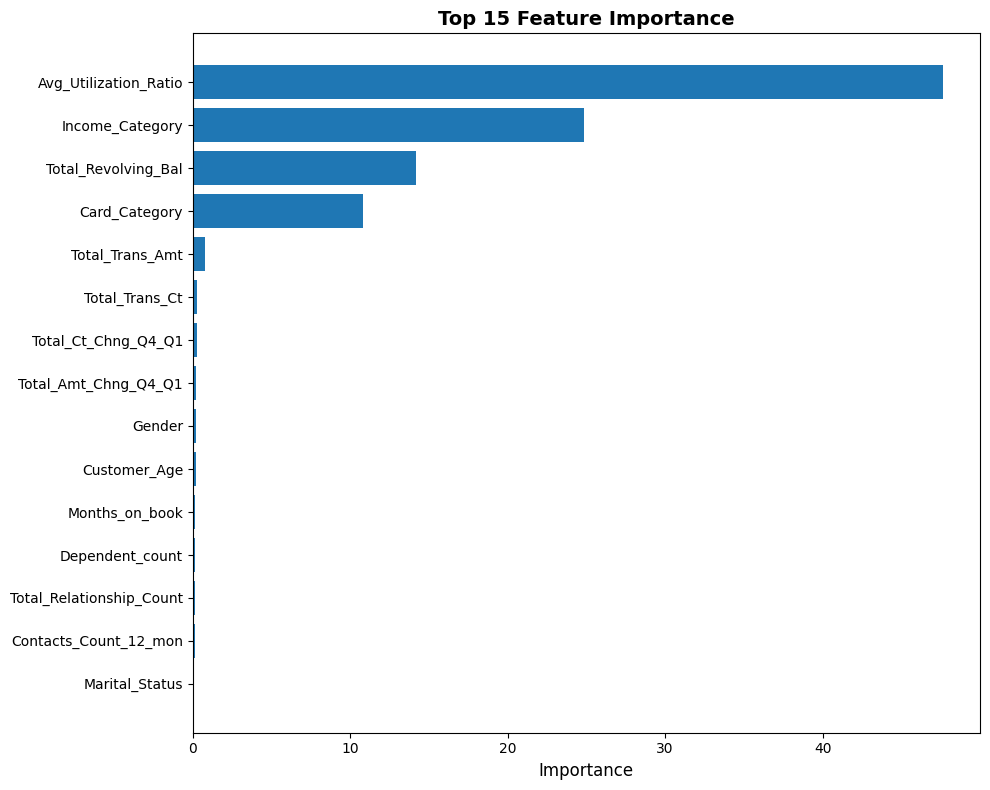

In [12]:
y_train_pred = cb_model.predict(X_train_cb)
y_val_pred = cb_model.predict(X_val_cb)
y_test_pred = cb_model.predict(X_test_cb)

# y_train_pred = np.exp(y_train_pred)
# y_val_pred = np.exp(y_val_pred)
# y_test_pred = np.exp(y_test_pred)

# y_train_actual = np.exp(y_train)
# y_val_actual = np.exp(y_val)
# y_test_actual = np.exp(y_test)

feature_importance = plot_feature_importance(cb_model, X_train_cb, top_n=15)

In [14]:
def calculate_cb_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:   {mse:.4f}')
    print(f'  RMSE:  {rmse:.4f}')
    print(f'  MAE:   {mae:.4f}')
    print(f'  R²:    {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики CatBoost модели')
print('=' * 50)

train_cb_metrics = calculate_cb_metrics(y_train, y_train_pred, 'TRAIN')
val_cb_metrics = calculate_cb_metrics(y_val, y_val_pred, 'VALIDATION')
test_cb_metrics = calculate_cb_metrics(y_test, y_test_pred, 'TEST')

print('\n' + '=' * 50)

joblib.dump(cb_model, '../artifacts/model_catboost.pkl')
print("\nМодель сохранена в '../artifacts/model_catboost.pkl'")

Метрики CatBoost модели

TRAIN:
  MSE:   7398744.3365
  RMSE:  2720.0633
  MAE:   1281.4204
  R²:    0.9086

VALIDATION:
  MSE:   9788067.6410
  RMSE:  3128.5888
  MAE:   1509.8022
  R²:    0.8878

TEST:
  MSE:   9231991.9357
  RMSE:  3038.4193
  MAE:   1441.8705
  R²:    0.8880


Модель сохранена в '../artifacts/model_catboost.pkl'


In [ ]:
with mlflow.start_run(run_name="Catboost"):
    
    # 1. Параметры модели и обучения
    mlflow.log_params(config)   # сразу весь словарь, или по одному
    mlflow.log_param("data_hash", data_hash)
    
    # 2. Метрики лосса
    mlflow.log_metrics({
        "train_mse": train_cb_metrics["MSE"],
        "train_rmse": train_cb_metrics["RMSE"],
        "train_mae": train_cb_metrics["MAE"],
        "train_r2": train_cb_metrics["R2"],
        "val_mse": val_cb_metrics["MSE"],
        "val_rmse": val_cb_metrics["RMSE"],
        "val_mae": val_cb_metrics["MAE"],
        "val_r2": val_cb_metrics["R2"],
        "test_mse": test_cb_metrics["MSE"],
        "test_rmse": test_cb_metrics["RMSE"],
        "test_mae": test_cb_metrics["MAE"],
        "test_r2": test_cb_metrics["R2"],
    })
    
    # 3. Сохранение модели (после того, как model загружена с best_model_state)
    mlflow.sklearn.log_model(cb_model, "model")
    
    # 4. Сохранение конфигурационного файла как артефакта
    mlflow.log_artifact("../artifacts/CB_mlflow/catboost_config.json")
    mlflow.log_artifact(data_path, "data")
    

2026/05/10 15:52:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 15:52:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


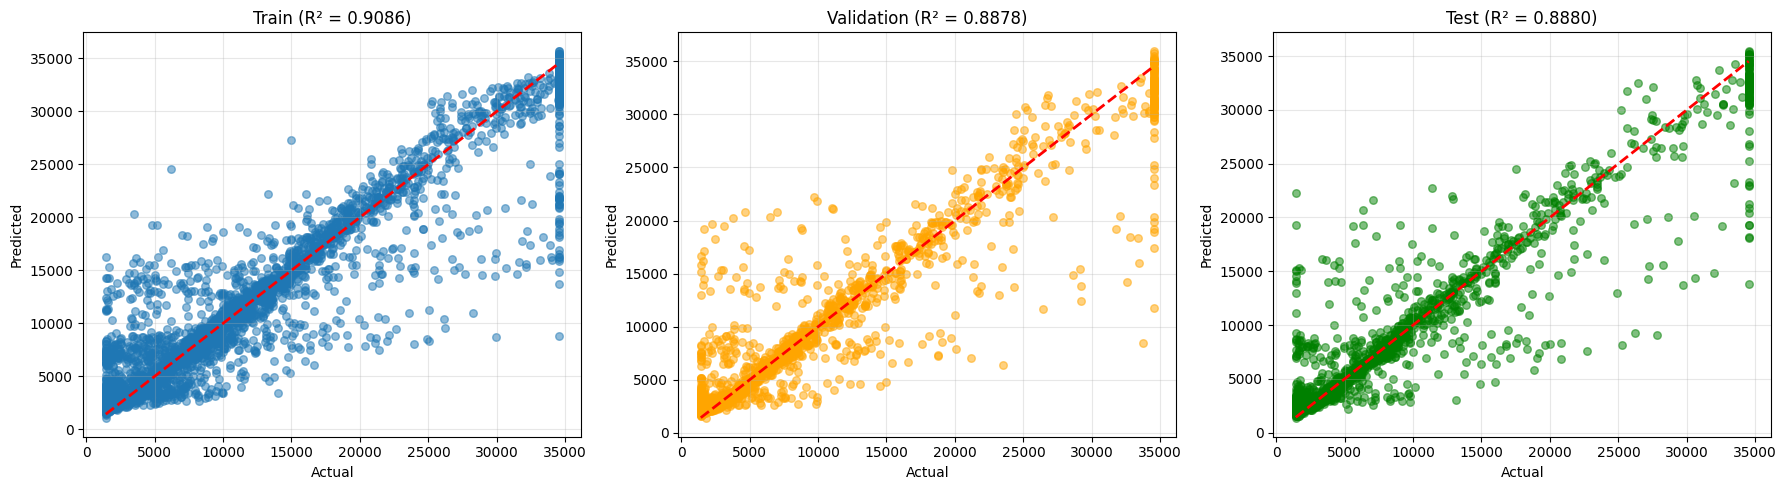

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (R² = {train_cb_metrics["R2"]:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([y_val.min(), y_val.max()], 
             [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Validation (R² = {val_cb_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='green')
axes[2].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test (R² = {test_cb_metrics["R2"]:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 50)
print("Тюнинг гиперпараметров CatBoost (Optuna)")
print("=" * 50)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'depth': trial.suggest_int('depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 6),
        'random_state': SEED,
        'loss_function': 'RMSE',
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
    }
    
    model = CatBoostRegressor(**params, verbose=False)
    model.fit(X_train_cb, y_train, cat_features=cat_cols, eval_set=[(X_val_cb, y_val)])
    
    score = model.score(X_val_cb, y_val)
    return score

study = optuna.create_study(
    direction='maximize', 
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

print("\nЗапуск оптимизации...")
study.optimize(objective, n_trials=100, n_jobs=1, show_progress_bar=True)

print(f"\nЛучшие параметры: {study.best_params}")
print(f"Лучший R²: {study.best_value:.4f}")


Тюнинг гиперпараметров CatBoost (Optuna)

Запуск оптимизации...


Best trial: 64. Best value: 0.890744: 100%|██████████| 100/100 [41:42<00:00, 25.02s/it]


Лучшие параметры: {'iterations': 600, 'depth': 9, 'learning_rate': 0.061502811982602434, 'l2_leaf_reg': 1.3240524100782431, 'grow_policy': 'Lossguide'}
Лучший R²: 0.8907


In [5]:
best_cb = joblib.load('../artifacts/model_catboost_best_optuna.pkl')
best_params = best_cb.get_all_params()

In [ ]:
import json, hashlib

config = {
    'iterations': study.best_params['iterations'],
    'depth': study.best_params['depth'],
    'learning_rate': study.best_params['learning_rate'],
    'l2_leaf_reg': study.best_params['l2_leaf_reg'],
    'grow_policy': study.best_params['grow_policy'],
    'loss_function': 'RMSE',
    "target_col": target_col,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "encoder": "TargetEncoder(smoothing=10.0)",
    "scaler": str(scaler)[:-2],
    "random_state": 42,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "data_alteration": "Only age<=80, Log of features" + ", Log of target" if traget_logged else "",
}

with open("../artifacts/CB_mlflow/catboost_optuna_config.json", "w") as f:
    json.dump(config, f, indent=2)

data_path = "../data/CreditPrediction.csv"
with open(data_path, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()
print(f"Data hash: {data_hash}")

Data hash: 0c491eccf4a9959c9cefab0a27497604


In [ ]:
best_params = study.best_params.copy()
best_params['verbose'] = False
best_params['loss_function'] = 'RMSE'
best_params['random_state'] = SEED

best_cb = CatBoostRegressor(**best_params)
best_cb.fit(X_train_cb, y_train, cat_features=cat_cols, eval_set=[(X_val_cb, y_val)])

y_train_pred_best = best_cb.predict(X_train_cb)
y_val_pred_best = best_cb.predict(X_val_cb)
y_test_pred_best = best_cb.predict(X_test_cb)

print(f"\nValidation | R²: {r2_score(y_val, y_val_pred_best):.4f} | RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_best)):.4f}")
print(f"Test      | R²: {r2_score(y_test, y_test_pred_best):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_best)):.4f}")


Validation | R²: 0.8907 | RMSE: 3086.9984
Test      | R²: 0.8862 | RMSE: 3061.9715


In [19]:
def calculate_cb_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:   {mse:.4f}')
    print(f'  RMSE:  {rmse:.4f}')
    print(f'  MAE:   {mae:.4f}')
    print(f'  R²:    {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики CatBoost модели')
print('=' * 50)

train_cb_metrics = calculate_cb_metrics(y_train, y_train_pred_best, 'TRAIN')
val_cb_metrics = calculate_cb_metrics(y_val, y_val_pred_best, 'VALIDATION')
test_cb_metrics = calculate_cb_metrics(y_test, y_test_pred_best, 'TEST')

print('\n' + '=' * 50)

joblib.dump(best_cb, '../artifacts/model_catboost_best_optuna.pkl')
print("\nМодель сохранена в '../artifacts/model_catboost_best_optuna.pkl'")

Метрики CatBoost модели

TRAIN:
  MSE:   4370510.3992
  RMSE:  2090.5766
  MAE:   984.2606
  R²:    0.9460

VALIDATION:
  MSE:   9529558.8629
  RMSE:  3086.9984
  MAE:   1392.8033
  R²:    0.8907

TEST:
  MSE:   9375669.1669
  RMSE:  3061.9715
  MAE:   1347.6746
  R²:    0.8862


Модель сохранена в '../artifacts/model_catboost_best_optuna.pkl'


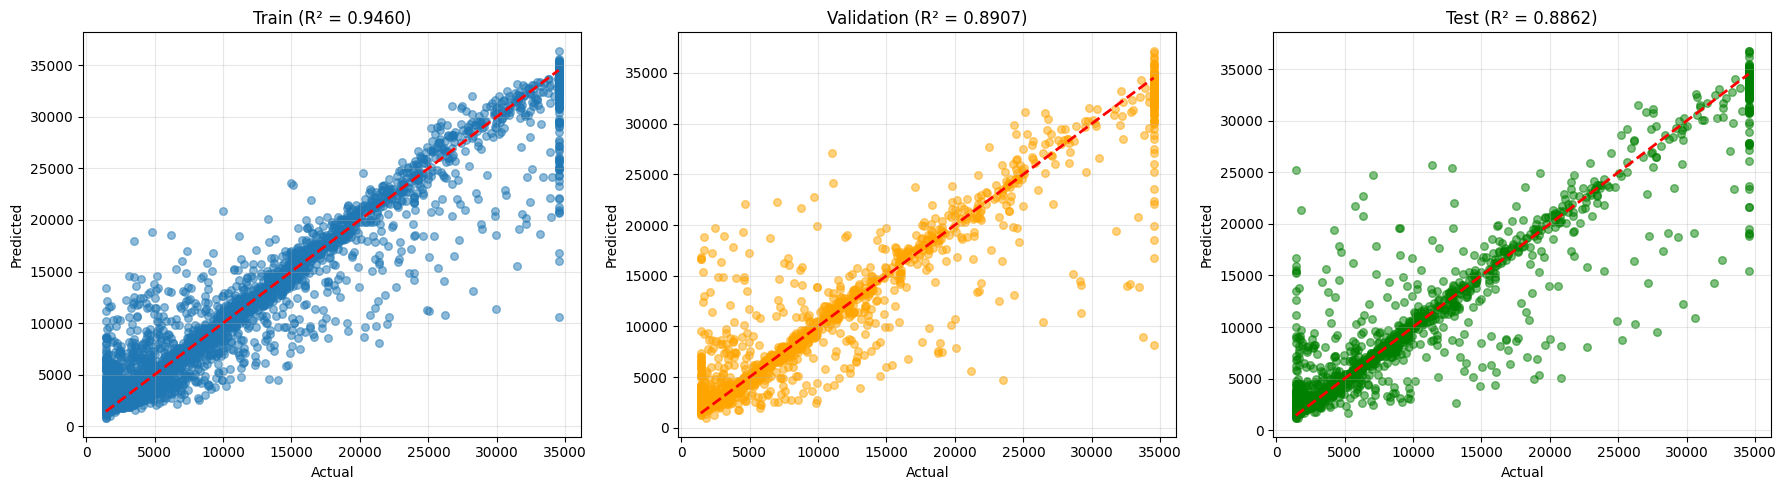

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_train, y_train_pred_best, alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (R² = {train_cb_metrics["R2"]:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val, y_val_pred_best, alpha=0.5, s=30, color='orange')
axes[1].plot([y_val.min(), y_val.max()], 
             [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Validation (R² = {val_cb_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test, y_test_pred_best, alpha=0.5, s=30, color='green')
axes[2].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test (R² = {test_cb_metrics["R2"]:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
with mlflow.start_run(run_name="Catboost"):
    
    # 1. Параметры модели и обучения
    mlflow.log_params(config)   # сразу весь словарь, или по одному
    mlflow.log_param("data_hash", data_hash)
    
    # 2. Метрики лосса
    mlflow.log_metrics({
        "train_mse": train_cb_metrics["MSE"],
        "train_rmse": train_cb_metrics["RMSE"],
        "train_mae": train_cb_metrics["MAE"],
        "train_r2": train_cb_metrics["R2"],
        "val_mse": val_cb_metrics["MSE"],
        "val_rmse": val_cb_metrics["RMSE"],
        "val_mae": val_cb_metrics["MAE"],
        "val_r2": val_cb_metrics["R2"],
        "test_mse": test_cb_metrics["MSE"],
        "test_rmse": test_cb_metrics["RMSE"],
        "test_mae": test_cb_metrics["MAE"],
        "test_r2": test_cb_metrics["R2"],
    })
    
    # 3. Сохранение модели (после того, как model загружена с best_model_state)
    mlflow.sklearn.log_model(best_cb, "model")
    
    # 4. Сохранение конфигурационного файла как артефакта
    mlflow.log_artifact("../artifacts/CB_mlflow/catboost_optuna_config.json")
    mlflow.log_artifact(data_path, "data")
    

2026/05/10 22:53:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 22:53:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
